# 02 Utvalg
Data Mining & Analytics – Samling 2, dag 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook") # sett standard stil for plott
plt.rcParams["figure.figsize"] = (8, 4.5) # sett standard figurstørrelse
rng = np.random.default_rng(42)   # sett seed for å få samme resultater hver gang

## Populasjon og utvalg

Vi lager en kunstig populasjon på 28 000 personer (ca antall innbyggere i Horten kommune) og ser på variabelen *ukentlig skjermtid (timer)*.
Fordelingen er bevisst skjev (mange med lite til moderat og noen få med veldig mye skjermtid).
I virkeligheten kjenner vi sjelden hele populasjonen slik vi gjør her. Dette gjør at vi kan sjekke hva som er «fasit».

Populasjonsgjennomsnitt (μ): 12.00 timer
Populasjonsstandardavvik (σ): 8.48 timer


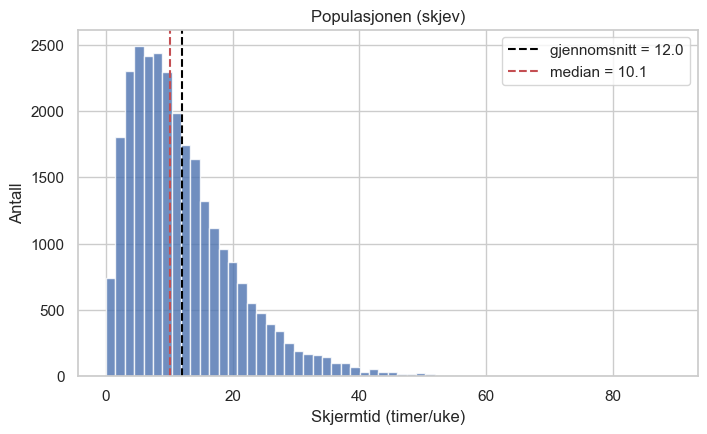

In [2]:
populasjon = rng.gamma(shape=2.0, scale=6.0, size=28000)      # skjev fordeling
mu, sigma = populasjon.mean(), populasjon.std()
print(f"Populasjonsgjennomsnitt (μ): {mu:.2f} timer")
print(f"Populasjonsstandardavvik (σ): {sigma:.2f} timer")

plt.hist(populasjon, bins=60, color="C0", alpha=0.8)
plt.axvline(mu, color="black", ls="--", label=f"gjennomsnitt = {mu:.1f}")
plt.axvline(np.median(populasjon), color="C3", ls="--", label=f"median = {np.median(populasjon):.1f}")
plt.xlabel("Skjermtid (timer/uke)")
plt.ylabel("Antall")
plt.title("Populasjonen (skjev)")
plt.legend()
plt.show()

Vi trekker et tilfeldig utvalg på n = 30 og regner ut gjennomsnitt og standardavvik. Hva blir utvalgsgjennomsnittet?

In [5]:
n = 50
utvalg = rng.choice(populasjon, size=n, replace=False) # trekker utvalg uten tilbakelegging
print(f"x̄ = {utvalg.mean():.2f}   (μ = {mu:.2f})")
print(f"s  = {utvalg.std():.2f}   (σ = {sigma:.2f})")
print(f"SE  = {utvalg.std() / np.sqrt(n):.2f}")

x̄ = 11.89   (μ = 12.00)
s  = 8.97   (σ = 8.48)
SE  = 1.27


gjennomsnittet for utvalget er ikke lik gjennomsnittet for populasjonen, og hvis vi trekker et nytt utvalg får vi et nytt gjennomsnitt for utvalget.
Dette er selve poenget: statistikken varierer fra utvalg til utvalg. Hvor mye? Det svarer utvalgsfordelingen på.

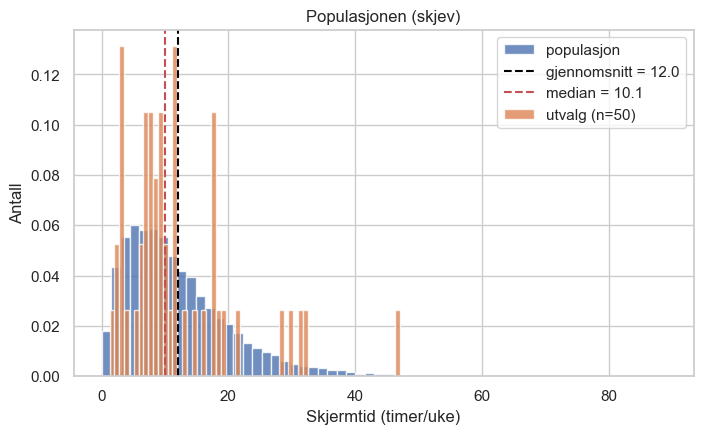

In [6]:
plt.hist(populasjon, bins=60, color="C0", alpha=0.8, density=True, label="populasjon")
plt.axvline(mu, color="black", ls="--", label=f"gjennomsnitt = {mu:.1f}")
plt.axvline(np.median(populasjon), color="C3", ls="--", label=f"median = {np.median(populasjon):.1f}")
plt.hist(utvalg, bins=60, color="C1", alpha=0.8, density=True, label=f"utvalg (n={n})")
plt.xlabel("Skjermtid (timer/uke)")
plt.ylabel("Antall")
plt.title("Populasjonen (skjev)")
plt.legend()
plt.show()

In [7]:
n = 400
utvalg = rng.choice(populasjon, size=n, replace=False) # trekker utvalg uten tilbakelegging
print(f"x̄ = {utvalg.mean():.2f}   (μ = {mu:.2f})")
print(f"s  = {utvalg.std():.2f}   (σ = {sigma:.2f})")
print(f"SE  = {utvalg.std() / np.sqrt(n):.2f}")

x̄ = 12.73   (μ = 12.00)
s  = 8.49   (σ = 8.48)
SE  = 0.42


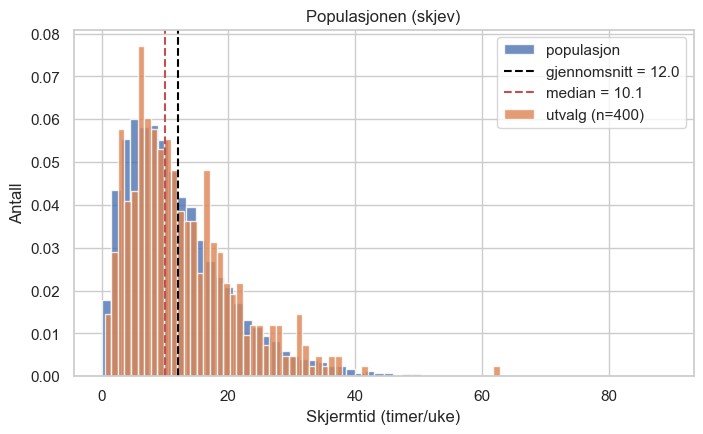

In [8]:
plt.hist(populasjon, bins=60, color="C0", alpha=0.8,density=True, label="populasjon")
plt.axvline(mu, color="black", ls="--", label=f"gjennomsnitt = {mu:.1f}")
plt.axvline(np.median(populasjon), color="C3", ls="--", label=f"median = {np.median(populasjon):.1f}")
plt.hist(utvalg, bins=60, color="C1", alpha=0.8, density=True, label=f"utvalg (n={n})")
plt.xlabel("Skjermtid (timer/uke)")
plt.ylabel("Antall")
plt.title("Populasjonen (skjev)")
plt.legend()
plt.show()

In [9]:
n = 1200
utvalg = rng.choice(populasjon, size=n, replace=False) # trekker utvalg uten tilbakelegging
print(f"x̄ = {utvalg.mean():.2f}   (μ = {mu:.2f})")
print(f"s  = {utvalg.std():.2f}   (σ = {sigma:.2f})")
print(f"SE  = {utvalg.std() / np.sqrt(n):.2f}")

x̄ = 12.05   (μ = 12.00)
s  = 8.65   (σ = 8.48)
SE  = 0.25


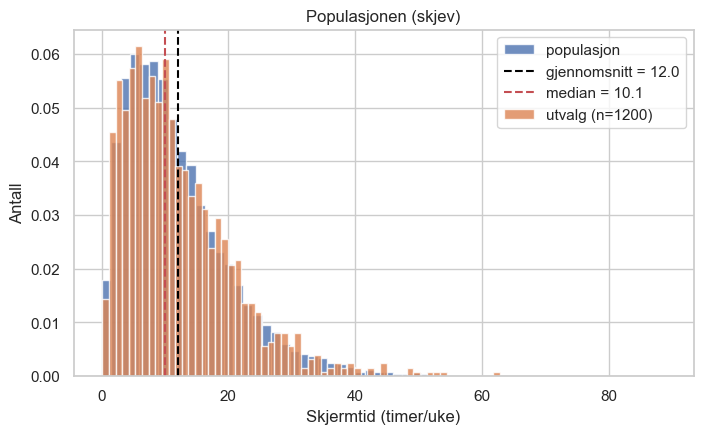

In [10]:
plt.hist(populasjon, bins=60, color="C0", alpha=0.8,density=True, label="populasjon")
plt.axvline(mu, color="black", ls="--", label=f"gjennomsnitt = {mu:.1f}")
plt.axvline(np.median(populasjon), color="C3", ls="--", label=f"median = {np.median(populasjon):.1f}")
plt.hist(utvalg, bins=60, color="C1", alpha=0.8, density=True, label=f"utvalg (n={n})")
plt.xlabel("Skjermtid (timer/uke)")
plt.ylabel("Antall")
plt.title("Populasjonen (skjev)")
plt.legend()
plt.show()

Standardavviket til $\bar{x}$ kalles standardfeilen (SE) og er $\sigma/\sqrt{n}$ – den krymper med kvadratroten av n.
For å halvere usikkerheten må vi altså firedoble utvalget.

## 95% Konfidensintervall (CI) – hva betyr «95 %» i denne konteksten?


In [11]:
n = 30
u = rng.choice(populasjon, n)
se = u.std() / np.sqrt(n)
t_krit = stats.t.ppf(0.975, df=n - 1)
ci = (u.mean() - t_krit * se, u.mean() + t_krit * se)
print(f"x̄ = {u.mean():.2f},  SE = {se:.2f},  95 % CI = [{ci[0]:.2f}, {ci[1]:.2f}]")
print("Med scipy:", stats.t.interval(0.95, df=n - 1, loc=u.mean(), scale=se))

x̄ = 11.55,  SE = 1.20,  95 % CI = [9.09, 14.02]
Med scipy: (np.float64(9.092200570312507), np.float64(14.016985058234141))


Hvis vi gjentok hele studien/forsøket mange ganger, ville ca. 95 % av intervallene inneholdt den sanne μ.

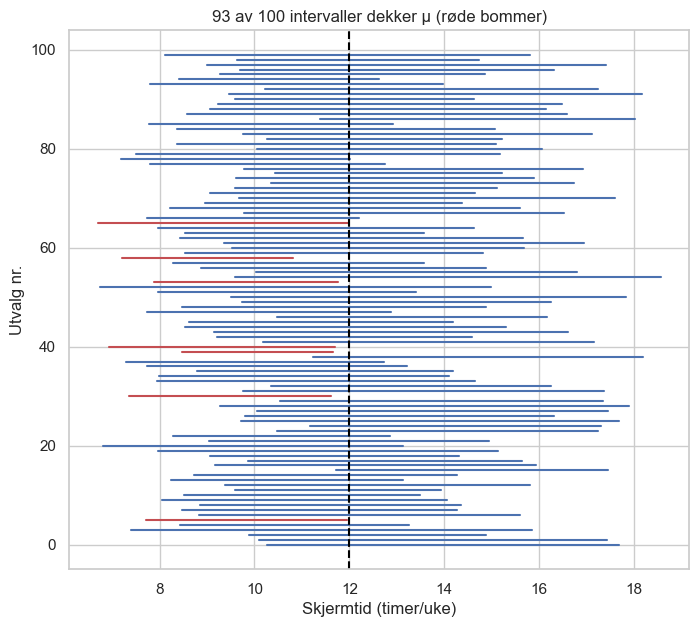

In [12]:
n, antall = 30, 100
dekker = []
fig, ax = plt.subplots(figsize=(8, 7))
for i in range(antall):
    u = rng.choice(populasjon, n)
    se = u.std(ddof=1) / np.sqrt(n)
    lo, hi = stats.t.interval(0.95, df=n - 1, loc=u.mean(), scale=se)
    treff = lo <= mu <= hi
    dekker.append(treff)
    ax.plot([lo, hi], [i, i], color="C0" if treff else "C3", lw=1.5)
ax.axvline(mu, color="black", ls="--")
ax.set_xlabel("Skjermtid (timer/uke)")
ax.set_ylabel("Utvalg nr.")
ax.set_title(f"{sum(dekker)} av {antall} intervaller dekker μ (røde bommer)")
plt.show()